# 04 — Module C: Seq2Seq EN→DE Translation
## Universal Sequence Lab · Assignment 3

**Task:** Neural Machine Translation from English to German on the **Multi30k** dataset.

**Architecture:**
- Encoder: Stacked LSTM
- Attention: Bahdanau (Additive) Attention
- Decoder: LSTM with attention context vector
- Training: Teacher Forcing (ratio 0.5)

**Metric:** BLEU score (standard MT evaluation)

---

In [2]:
!pip install datasets sacrebleu seaborn -q

import sys
sys.path.append('/content/src')

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

from models import Encoder, Decoder, Seq2SeqTranslator
from dataset import get_translation_loaders
from train import train_model, plot_learning_curves, plot_attention_heatmap, \
                  count_parameters, compute_bleu, evaluate

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.8/100.8 kB 9.5 MB/s eta 0:00:00
Device: cuda


## 1. Load Data


In [3]:
BATCH_SIZE = 128
MAX_LEN    = 50

train_loader, val_loader, test_loader, src_vocab, tgt_vocab = \
    get_translation_loaders(batch_size=BATCH_SIZE, max_len=MAX_LEN)

SRC_VOCAB_SIZE = len(src_vocab)
TGT_VOCAB_SIZE = len(tgt_vocab)
PAD_IDX = tgt_vocab['<pad>']

print(f'EN vocab: {SRC_VOCAB_SIZE:,} | DE vocab: {TGT_VOCAB_SIZE:,}')

Loading Multi30k EN→DE dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train.jsonl: 0.00B [00:00, ?B/s]

val.jsonl: 0.00B [00:00, ?B/s]

test.jsonl: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/29000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1014 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1000 [00:00<?, ? examples/s]

Building source (EN) vocabulary...
  Vocabulary size: 7,964
Building target (DE) vocabulary...
  Vocabulary size: 9,762
  EN vocab: 7,964 | DE vocab: 9,762
  Train: 29000 | Val: 1014 | Test: 1000
EN vocab: 7,964 | DE vocab: 9,762


## 2. Build Model


In [4]:
# Hyperparameters
EMBED_DIM  = 256
HIDDEN_DIM = 512
N_LAYERS   = 2
DROPOUT    = 0.3
N_EPOCHS   = 25
LR         = 5e-4

encoder = Encoder(SRC_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
decoder = Decoder(TGT_VOCAB_SIZE, EMBED_DIM, HIDDEN_DIM, N_LAYERS, DROPOUT)
model   = Seq2SeqTranslator(encoder, decoder, DEVICE).to(DEVICE)

print('Model architecture:')
count_parameters(model)

# Weight initialization
def init_weights(m):
    for name, param in m.named_parameters():
        nn.init.uniform_(param.data, -0.08, 0.08)
model.apply(init_weights)
print('Weights initialized ✓')

Model architecture:
  Total params:     25,973,282
  Trainable params: 25,973,282
Weights initialized ✓


In [5]:
import os
os.makedirs('/content/models', exist_ok=True)

## 3. Train


In [6]:
# Ignore <pad> in loss
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

history = train_model(
    model, train_loader, val_loader, optimizer, criterion, DEVICE,
    n_epochs=N_EPOCHS, task='seq2seq',
    scheduler=scheduler, model_name='Seq2Seq+Attention',
    save_path='/content/models/seq2seq_best.pt'
)
histories = {'Seq2Seq+Attention': history}

[Seq2Seq+Attention] Epoch 01/25 | Train Loss: 3.8497 | Val Loss: 3.6008 | Val Loss: 3.6008 | 88.8s
[Seq2Seq+Attention] Epoch 02/25 | Train Loss: 3.1607 | Val Loss: 3.3269 | Val Loss: 3.3269 | 92.8s
[Seq2Seq+Attention] Epoch 03/25 | Train Loss: 2.8077 | Val Loss: 2.9844 | Val Loss: 2.9844 | 91.3s
[Seq2Seq+Attention] Epoch 04/25 | Train Loss: 2.4926 | Val Loss: 2.7700 | Val Loss: 2.7700 | 93.0s
[Seq2Seq+Attention] Epoch 05/25 | Train Loss: 2.2386 | Val Loss: 2.6492 | Val Loss: 2.6492 | 91.6s
[Seq2Seq+Attention] Epoch 06/25 | Train Loss: 2.0849 | Val Loss: 2.5795 | Val Loss: 2.5795 | 92.4s
[Seq2Seq+Attention] Epoch 07/25 | Train Loss: 1.9473 | Val Loss: 2.5170 | Val Loss: 2.5170 | 91.2s
[Seq2Seq+Attention] Epoch 08/25 | Train Loss: 1.8241 | Val Loss: 2.5116 | Val Loss: 2.5116 | 91.1s
[Seq2Seq+Attention] Epoch 09/25 | Train Loss: 1.7251 | Val Loss: 2.4598 | Val Loss: 2.4598 | 91.6s
[Seq2Seq+Attention] Epoch 10/25 | Train Loss: 1.6505 | Val Loss: 2.4637 | Val Loss: 2.4637 | 91.5s
[Seq2Seq+A

## 4. Learning Curves


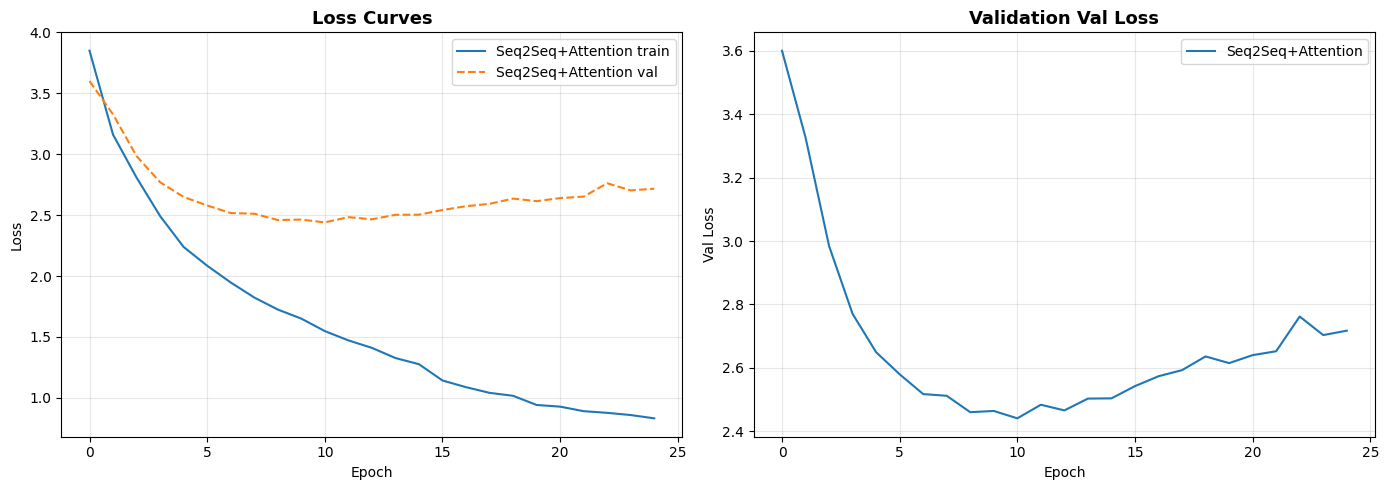

In [7]:
fig = plot_learning_curves(histories, task='seq2seq')

## 5. BLEU Score Evaluation


In [8]:
model.load_state_dict(torch.load('/content/models/seq2seq_best.pt', map_location=DEVICE))

bleu = compute_bleu(model, test_loader, tgt_vocab.token2idx, DEVICE, max_samples=1000)
print(f'Test BLEU score: {bleu:.2f}')
print('(Random baseline: ~0, Human: ~100, Good NMT: 25-35)')

Test BLEU score: 51.06
(Random baseline: ~0, Human: ~100, Good NMT: 25-35)


## 6. Qualitative Translation Examples


In [9]:
from datasets import load_dataset
ds = load_dataset('bentrevett/multi30k')

def translate(model, sentence, src_vocab, tgt_vocab, device, max_len=50):
    model.eval()
    ids = src_vocab.encode_with_eos(sentence)
    src = torch.tensor(ids).unsqueeze(0).to(device)

    with torch.no_grad():
        enc_out, hidden, cell = model.encoder(src)

    inv_tgt = {v: k for k, v in tgt_vocab.token2idx.items()
                if isinstance(k, str)}
    dec_input = torch.tensor([tgt_vocab['<sos>']]).to(device)
    translation, attn_list = [], []

    with torch.no_grad():
        for _ in range(max_len):
            pred, hidden, cell, attn = model.decoder(
                dec_input, hidden, cell, enc_out)
            top1 = pred.argmax(1)
            attn_list.append(attn.squeeze(0).cpu())
            if top1.item() == tgt_vocab['<eos>']:
                break
            translation.append(inv_tgt.get(top1.item(), '<unk>'))
            dec_input = top1

    return ' '.join(translation), torch.stack(attn_list)

print('Sample translations:\n')
for i in random.sample(range(len(ds['test'])), 5):
    ex = ds['test'][i]
    trans, _ = translate(model, ex['en'], src_vocab, tgt_vocab, DEVICE)
    print(f'EN:       {ex["en"]}')
    print(f'DE (ref): {ex["de"]}')
    print(f'DE (pred):{trans}')
    print()

Sample translations:

EN:       A man lounges on a red sofa in a furniture showroom.
DE (ref): Ein Mann liegt auf einem Sofa in einem Möbelhaus.
DE (pred):ein <unk> auf einem roten <unk> in einer <unk>

EN:       A woman with a drink and a woman with a cellphone.
DE (ref): Eine Frau mit einem Getränk und eine Frau mit einem Mobiltelefon.
DE (pred):eine <unk> mit einem <unk> und eine <unk> mit einem <unk>

EN:       The boy jumps onto his soccer player brother.
DE (ref): Ein Junge springt auf seinen Fußball spielenden Bruder.
DE (pred):junge springt über seinen <unk>

EN:       A woman eating in the grass on a beautiful day.
DE (ref): Eine Frau isst an einem schönen Tag auf dem Gras.
DE (pred):eine <unk> im <unk> auf einem <unk> <unk>

EN:       A young child wearing green boots playing in a mud puddle
DE (ref): Ein kleines Kind in grünen Stiefeln spielt in einer Schlammpfütze.
DE (pred):ein kleines <unk> in grünen <unk> spielt in einer <unk> <unk>



## 7. Attention Heatmap Visualization


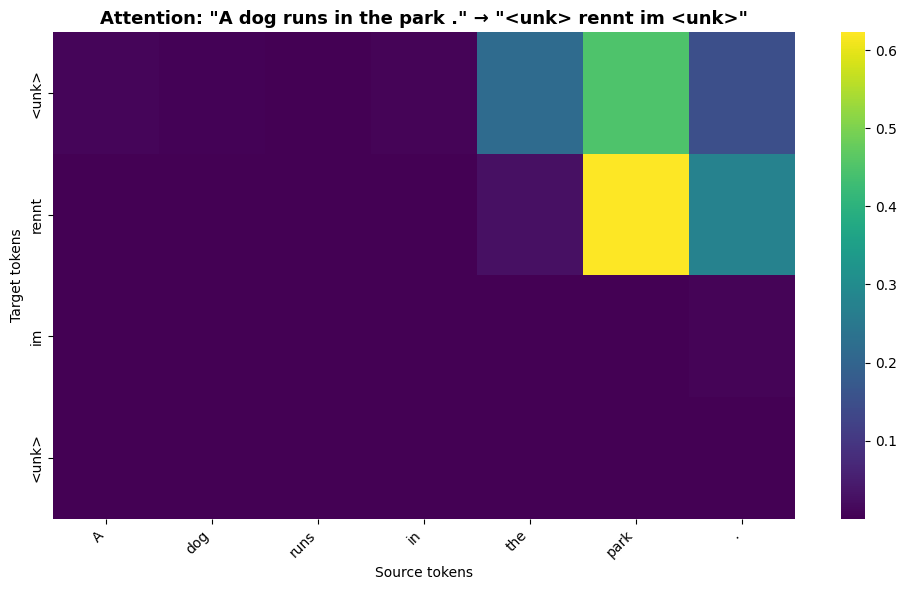

Bright cells = the decoder attended strongly to that source token


In [10]:
# Pick a short example for clear visualization
example = 'A dog runs in the park .'
translation, attn_weights = translate(model, example, src_vocab, tgt_vocab, DEVICE)

src_tokens = example.split()
tgt_tokens = translation.split()
attn_matrix = attn_weights[:len(tgt_tokens), :len(src_tokens)].numpy()

plot_attention_heatmap(
    attn_matrix, src_tokens, tgt_tokens,
    title=f'Attention: "{example}" → "{translation}"'
)
print('Bright cells = the decoder attended strongly to that source token')

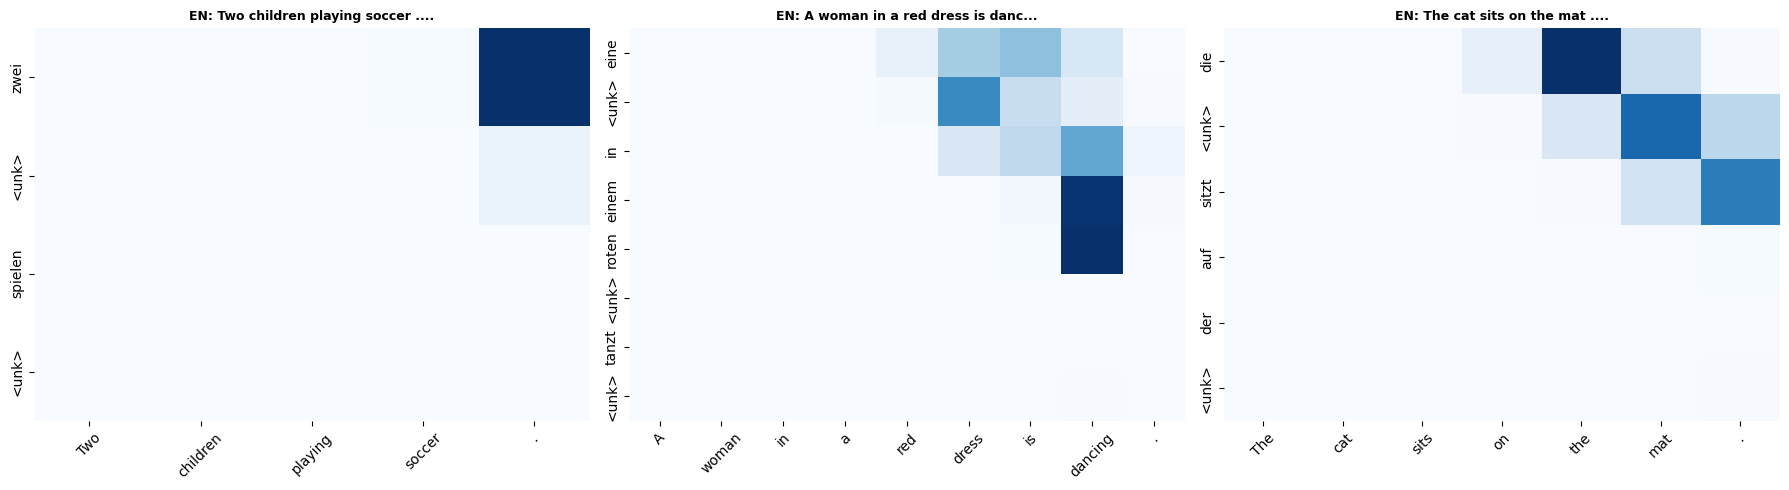

In [11]:
# Multiple examples
examples = [
    'Two children playing soccer .',
    'A woman in a red dress is dancing .',
    'The cat sits on the mat .'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
import seaborn as sns

for ax, sent in zip(axes, examples):
    trans, attn = translate(model, sent, src_vocab, tgt_vocab, DEVICE)
    src_t = sent.split()
    tgt_t = trans.split()
    mat = attn[:len(tgt_t), :len(src_t)].numpy()
    sns.heatmap(mat, xticklabels=src_t, yticklabels=tgt_t,
                cmap='Blues', ax=ax, cbar=False)
    ax.set_title(f'EN: {sent[:30]}...', fontsize=9, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('attention_heatmaps.png', bbox_inches='tight')
plt.show()